In [1]:
!pip install timm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 33.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 13.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 67.2 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.8.93
    Uninstalling nvidia-nvjitlink-cu12-12.8.93:
      Successfully uninstalled nvidia-nvjitlink-cu12-12.8.93
  Attempting uninstall: nvidia-curand-cu12
    Found existing installation: nvidia-curand-cu12 10.3.9.90
    Uninstalling nvidia-curand-cu12-10.3.9.90:
      Successfully uninstalled nvidia-curand-cu12-10.3.9.90
  Attemptin

In [2]:
import os
import numpy as np
import torch
import random
from glob import glob
from PIL import Image
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

import timm  # for pretrained ViT models
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms
from sklearn.metrics import f1_score, confusion_matrix


In [3]:
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


In [4]:
class AlzheimerDataset(Dataset):
    def __init__(self, root, data_type, transform=None):
        self.transform = transform
        self.image_paths = glob(f"{root}/{data_type}/*/*")
        self.classes = sorted({os.path.basename(os.path.dirname(p)) for p in self.image_paths})
        self.class_to_idx = {cls: idx for idx, cls in enumerate(self.classes)}

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = Image.open(img_path).convert('RGB')
        label = self.class_to_idx[os.path.basename(os.path.dirname(img_path))]
        if self.transform:
            image = self.transform(image)
        return image, label


In [5]:
root = "/kaggle/input/best-alzheimer-mri-dataset-99-accuracy/Combined Dataset"

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

# Load full dataset
train_dataset = AlzheimerDataset(root=root, data_type="train", transform=transform)
train_len = int(0.8 * len(train_dataset))
val_len = len(train_dataset) - train_len
train_ds, val_ds = random_split(train_dataset, [train_len, val_len])

# Load test dataset
test_dataset = AlzheimerDataset(root=root, data_type="test", transform=transform)



train_dl = DataLoader(train_ds, batch_size=32, shuffle=True)
val_dl   = DataLoader(val_ds, batch_size=32, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False)

classes = train_dataset.classes
num_classes = len(classes)
print(f"Total test samples: {len(test_dataset)}")


Total test samples: 1279


In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.utils.class_weight import compute_class_weight
import timm
import os
import numpy as np
from torchvision import transforms

# === Setup ===
model_name = "vit_base_patch16_224"
save_prefix = "mri_vit_finetuned"
save_dir = "saved_models"
device = "cuda" if torch.cuda.is_available() else "cpu"

# === Data Augmentation & Normalization ===
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.5] * 3, [0.5] * 3)
])

# === Initialize ViT ===
model = timm.create_model(model_name=model_name, pretrained=True, num_classes=num_classes)

# === Gradual Unfreezing: Freeze all first
for param in model.parameters():
    param.requires_grad = False

# === Unfreeze last two blocks and head
for param in model.blocks[-2:].parameters():
    param.requires_grad = True
for param in model.head.parameters():
    param.requires_grad = True

model = model.to(device)

# === Extract labels from original dataset
train_labels = []
for i in train_ds.indices:
    _, label = train_dataset[i]
    train_labels.append(label)

# === Compute class weights
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
)
weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)

# === Loss with label smoothing ===
criterion = nn.CrossEntropyLoss(weight=weights_tensor, label_smoothing=0.1)

# === Optimizer ===
optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=3e-6, weight_decay=1e-4)

# === Scheduler: Cosine Annealing ===
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10)

print("ViT model initialized with advanced finetuning setup.")


Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

ViT model initialized with advanced finetuning setup.


In [7]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.utils.class_weight import compute_class_weight
import timm
import os
import numpy as np
from torchvision import transforms

# === Setup ===
model_name = "vit_base_patch16_224"
save_prefix = "mri_vit_finetuned"
save_dir = "saved_models"
device = "cuda" if torch.cuda.is_available() else "cpu"

# === Data Augmentation & Normalization ===

train_transform = transforms.Compose([
    transforms.Resize((256, 256)),                      # Slightly larger resize before crop
    transforms.RandomCrop((224, 224), padding=4),       # Helps with spatial robustness
    transforms.RandomHorizontalFlip(p=0.5),             # Mirror image
    transforms.RandomVerticalFlip(p=0.2),               # Less frequent than horizontal flip
    transforms.RandomRotation(degrees=15),              # Minor orientation shifts
    transforms.ColorJitter(brightness=0.1, contrast=0.1),  # Simulate lighting variations
    transforms.RandomGrayscale(p=0.1),                  # Reduce color reliance
    transforms.RandAugment(num_ops=2, magnitude=9),     # Add two random ops (robust)
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5]*3, std=[0.5]*3)
])


# === Extract labels from original dataset ===
train_labels = []
for i in train_ds.indices:
    _, label = train_dataset[i]
    train_labels.append(label)
num_classes = len(np.unique(train_labels)) 

# === Initialize ViT and remove default head ===
model = timm.create_model(model_name=model_name, pretrained=True)
model.reset_classifier(0) 

# === Define Custom Classification Head ===
model.head = nn.Sequential(
    nn.LayerNorm(model.num_features),
    nn.Linear(model.num_features, 512),
    nn.GELU(),
    nn.Dropout(0.4),
    nn.Linear(512, 256),
    nn.GELU(),
    nn.Dropout(0.3),
    nn.Linear(256, num_classes)
)


# === Unfreeze all transformer blocks ===
for param in model.parameters():
    param.requires_grad = True

# === Ensure LayerNorm layers are also trainable ===
for name, param in model.named_parameters():
    if "norm" in name:
        param.requires_grad = True

model = model.to(device)

# === Compute class weights from training labels ===
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
)
weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)

# === Loss Function: CrossEntropy with Label Smoothing ===
criterion = nn.CrossEntropyLoss(weight=weights_tensor, label_smoothing=0.1)

# === Optimizer ===
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)

# === Scheduler: Cosine Annealing with Warm Restarts ===
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=2, verbose=True)

print("ViT model fully initialized with custom head and advanced fine-tuning settings.")
import os
import torchmetrics
from tqdm import tqdm
import torch

class TrainValidation:
    def __init__(self, model, classes, tr_dl, val_dl, criterion, optimizer, scheduler, device,
                 save_dir="saved_models", save_prefix="model",
                 epochs=20, patience=5, threshold=0.01, dev_mode=False):

        self.model = model.to(device)
        self.classes = classes
        self.tr_dl = tr_dl
        self.val_dl = val_dl
        self.criterion = criterion
        self.optimizer = optimizer
        self.scheduler = scheduler
        self.device = device

        self.save_dir = save_dir
        self.save_prefix = save_prefix
        self.epochs = epochs
        self.patience = patience
        self.threshold = threshold
        self.dev_mode = dev_mode

        self.f1_metric = torchmetrics.F1Score(task="multiclass", num_classes=len(classes)).to(device)

        os.makedirs(save_dir, exist_ok=True)
        self.best_acc = 0
        self.not_improved = 0

        self.tr_losses, self.val_losses = [], []
        self.tr_accs, self.val_accs = [], []
        self.tr_f1s, self.val_f1s = [], []

    @staticmethod
    def to_device(batch, device):
        ims, gts = batch
        return ims.to(device), gts.to(device)

    def train_epoch(self):
        self.model.train()
        total_loss, correct = 0.0, 0
        self.f1_metric.reset()

        for idx, batch in tqdm(enumerate(self.tr_dl), desc="Training", total=len(self.tr_dl)):
            if self.dev_mode and idx > 1:
                break

            ims, gts = self.to_device(batch, self.device)

            preds = self.model(ims)
            loss = self.criterion(preds, gts)

            self.optimizer.zero_grad()
            loss.backward()
            self.optimizer.step()

            total_loss += loss.item()
            correct += (preds.argmax(1) == gts).sum().item()
            self.f1_metric.update(preds, gts)

        avg_loss = total_loss / len(self.tr_dl)
        avg_acc = correct / len(self.tr_dl.dataset)
        avg_f1 = self.f1_metric.compute().item()

        self.tr_losses.append(avg_loss)
        self.tr_accs.append(avg_acc)
        self.tr_f1s.append(avg_f1)

        return avg_loss, avg_acc, avg_f1

    def validate_epoch(self):
        self.model.eval()
        total_loss, correct = 0.0, 0
        self.f1_metric.reset()

        with torch.no_grad():
            for idx, batch in tqdm(enumerate(self.val_dl), desc="Validation", total=len(self.val_dl)):
                if self.dev_mode and idx > 1:
                    break

                ims, gts = self.to_device(batch, self.device)

                preds = self.model(ims)
                loss = self.criterion(preds, gts)

                total_loss += loss.item()
                correct += (preds.argmax(1) == gts).sum().item()
                self.f1_metric.update(preds, gts)

        avg_loss = total_loss / len(self.val_dl)
        avg_acc = correct / len(self.val_dl.dataset)
        avg_f1 = self.f1_metric.compute().item()

        self.val_losses.append(avg_loss)
        self.val_accs.append(avg_acc)
        self.val_f1s.append(avg_f1)

        return avg_loss, avg_acc, avg_f1

    def save_best_model(self, val_f1):
        if val_f1 > self.best_acc:
            self.best_acc = val_f1
            save_path = os.path.join(self.save_dir, f"{self.save_prefix}_best_model.pth")
            torch.save(self.model.state_dict(), save_path)
            print(f"Best model saved with F1-Score: {val_f1:.3f}")
            self.not_improved = 0
        else:
            self.not_improved += 1
            print(f"No improvement for {self.not_improved} epoch(s).")

    def run(self):
        print("Starting fine-tuned training...\n")
        for epoch in range(self.epochs):
            if self.dev_mode and epoch > 1:
                break

            print(f"=== Epoch {epoch + 1}/{self.epochs} ===")
            train_loss, train_acc, train_f1 = self.train_epoch()
            print(f"Train — Loss: {train_loss:.3f} | Acc: {train_acc:.3f} | F1: {train_f1:.3f}")

            val_loss, val_acc, val_f1 = self.validate_epoch()
            print(f"Val   — Loss: {val_loss:.3f} | Acc: {val_acc:.3f} | F1: {val_f1:.3f}")

            self.save_best_model(val_f1)

            if self.scheduler is not None:
                self.scheduler.step(val_f1)

            if self.not_improved >= self.patience:
                print("Early stopping triggered.")
                break

        print(" Training completed.")

trainer = TrainValidation(
    model=model,
    classes=classes,
    tr_dl=train_dl,
    val_dl=val_dl,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
    device=device,
    save_dir=save_dir,
    save_prefix=save_prefix,
    epochs=20,
    patience=5,
    threshold=0.01,
    dev_mode=False
)
trainer.run()

/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


ViT model fully initialized with custom head and advanced fine-tuning settings.
Starting fine-tuned training...

=== Epoch 1/20 ===


Training: 100%|██████████| 256/256 [02:50<00:00,  1.50it/s]


Train — Loss: 1.169 | Acc: 0.427 | F1: 0.427


Validation: 100%|██████████| 64/64 [00:26<00:00,  2.40it/s]


...

Val   — Loss: 0.425 | Acc: 0.966 | F1: 0.966
Best model saved with F1-Score: 0.966
=== Epoch 20/20 ===


Training: 100%|██████████| 256/256 [02:53<00:00,  1.47it/s]


Train — Loss: 0.380 | Acc: 0.987 | F1: 0.987


Validation: 100%|██████████| 64/64 [00:17<00:00,  3.68it/s]

Val   — Loss: 0.429 | Acc: 0.962 | F1: 0.962
No improvement for 1 epoch(s).
 Training completed.


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 66.7 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.4.6-py3-none-any.whl size=38339 sha256=ecb489b776a11c943dae0820da2900769f4531aa5d42505e848bf7bc860644ce
  Stored in directory: /root/.cache/pip/wheels/5d/90/92/0661d038b2e6ce71cad21432f92c50b1d79887bd5eb82ff3b1
Successfully built grad-cam


Inference: 100%|██████████| 40/40 [00:18<00:00,  2.19it/s]



✅ Accuracy on test set: 0.913

📊 Classification Report:
                      precision    recall  f1-score   support

     Mild Impairment       0.87      0.95      0.91       179
 Moderate Impairment       0.69      0.75      0.72        12
       No Impairment       0.97      0.91      0.93       640
Very Mild Impairment       0.87      0.91      0.89       448

            accuracy                           0.91      1279
           macro avg       0.85      0.88      0.86      1279
        weighted avg       0.92      0.91      0.91      1279



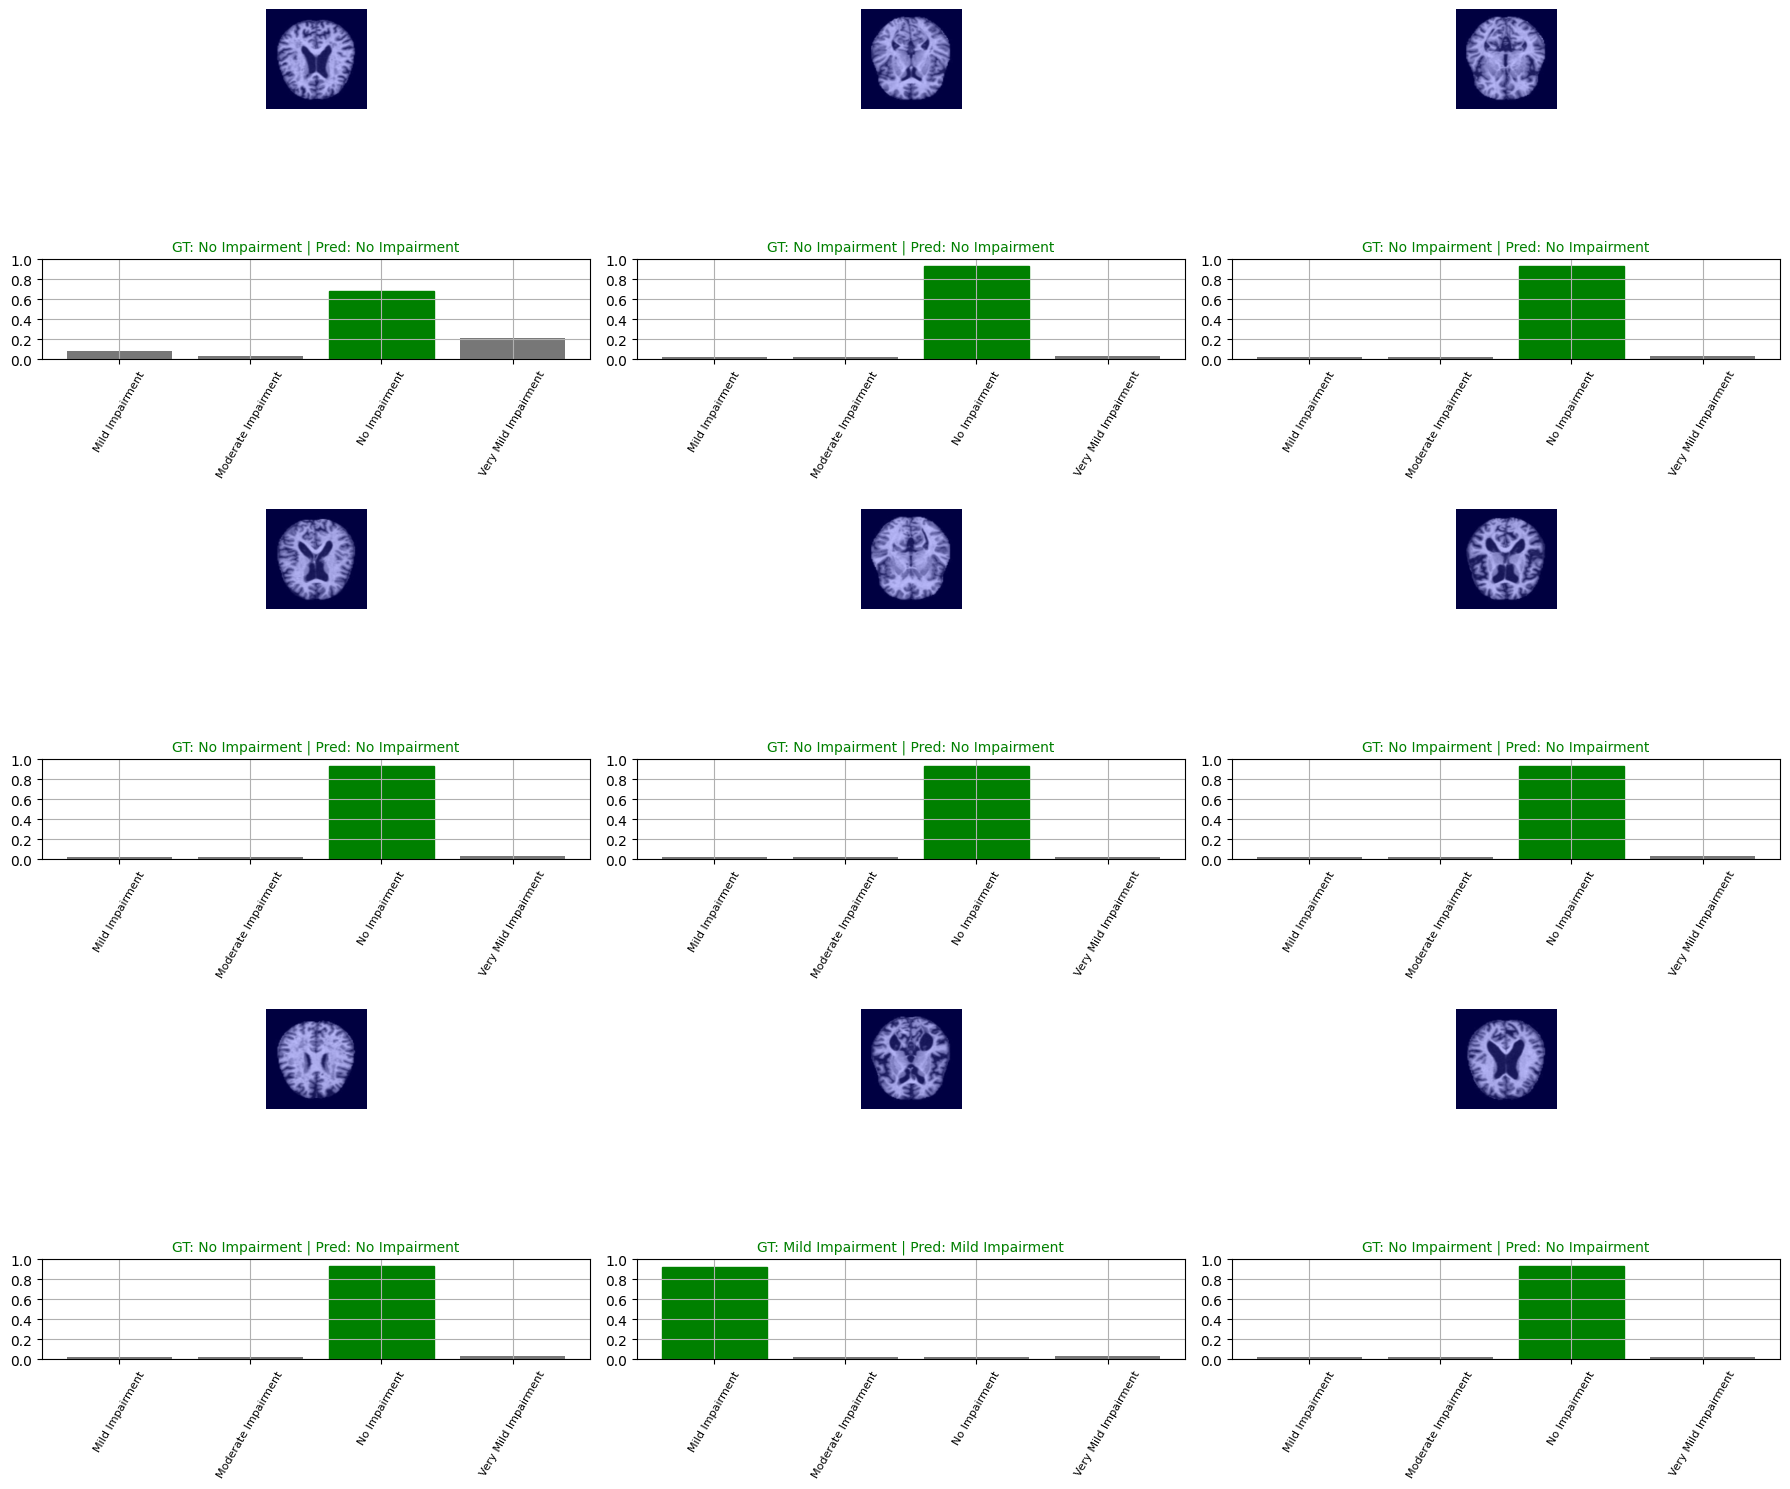

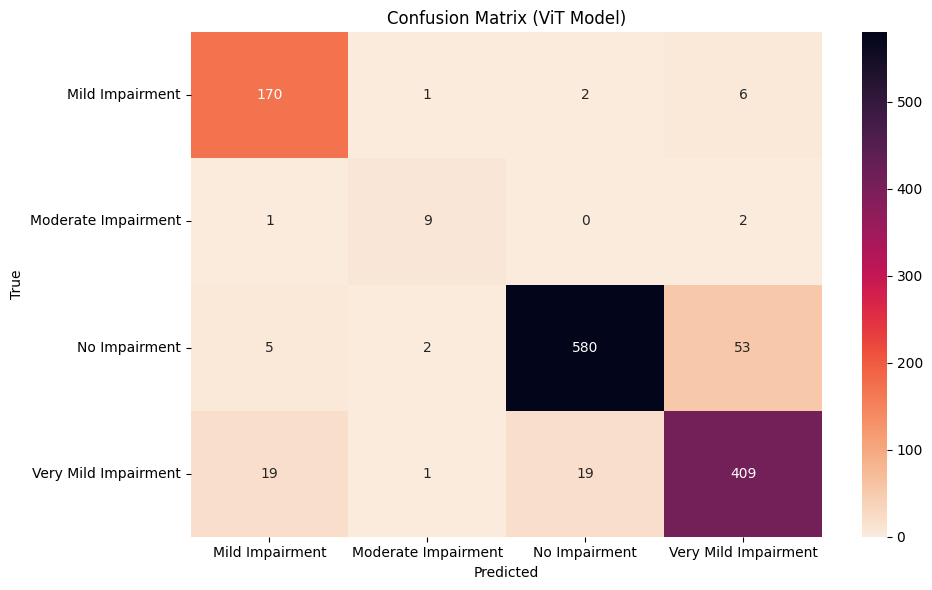

In [8]:
!pip install grad-cam==1.4.6
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from sklearn.metrics import classification_report, confusion_matrix
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
import cv2
import random

class Denormalize:
    def __init__(self, mean, std):
        self.mean = mean
        self.std = std
    def __call__(self, tensor):
        for t, m, s in zip(tensor, self.mean, self.std):
            t.mul_(s).add_(m)
        return tensor

class ModelInferenceVisualizer:
    def __init__(self, model, device, class_names=None, im_size=224, mean=[0.5]*3, std=[0.5]*3):
        self.model = model.eval().to(device)
        self.device = device
        self.class_names = class_names
        self.im_size = im_size
        self.denormalize = Denormalize(mean, std)

    def tensor_to_image(self, tensor):
        tensor = self.denormalize(tensor).permute(1, 2, 0)
        return tensor.cpu().numpy().clip(0, 1)

    def plot_value_array(self, logits, gt, class_names):
        probs = torch.nn.functional.softmax(logits, dim=1)
        pred_class = torch.argmax(probs, dim=1)
        plt.grid(True)
        plt.xticks(range(len(class_names)), class_names, rotation=60, fontsize=8)
        plt.yticks(np.arange(0.0, 1.1, 0.2))
        bars = plt.bar(range(len(class_names)), [p.item() for p in probs[0]], color="#777777")
        plt.ylim([0, 1])
        if pred_class.item() == gt:
            bars[pred_class].set_color('green')
        else:
            bars[pred_class].set_color('red')

    def generate_cam_visualization(self, image_tensor):
        def reshape_transform(tensor):
            tensor = tensor[:, 1:, :]
            H = W = int(tensor.shape[1] ** 0.5)
            return tensor.permute(0, 2, 1).reshape(-1, tensor.shape[2], H, W)

        target_layer = self.model.blocks[-1].norm1  # ViT large compatible
        cam = GradCAM(
            model=self.model,
            target_layers=[target_layer],
            use_cuda=(self.device == "cuda"),
            reshape_transform=reshape_transform
        )
        grayscale_cam = cam(input_tensor=image_tensor.unsqueeze(0))[0, :]
        grayscale_cam = (grayscale_cam - grayscale_cam.min()) / (grayscale_cam.max() - grayscale_cam.min() + 1e-8)
        _, H, W = image_tensor.shape
        grayscale_cam = cv2.resize(grayscale_cam, (W, H), interpolation=cv2.INTER_CUBIC)
        return grayscale_cam

    def infer_and_visualize(self, test_dl, num_images=6, images_per_row=3):
        preds, images, lbls, logitss = [], [], [], []
        correct, total = 0, 0

        with torch.no_grad():
            for im, gt in tqdm(test_dl, desc="Inference", total=len(test_dl)):
                im, gt = im.to(self.device), gt.to(self.device)
                logits = self.model(im)
                pred_class = torch.argmax(logits, dim=1)

                correct += (pred_class == gt).sum().item()
                total += gt.size(0)

                for i in range(im.size(0)):
                    images.append(im[i])
                    logitss.append(logits[i])
                    preds.append(pred_class[i].item())
                    lbls.append(gt[i].item())

        print(f"\n✅ Accuracy on test set: {(correct / total):.3f}")
        print("\n📊 Classification Report:")
        print(classification_report(lbls, preds, target_names=self.class_names))

        indices = random.sample(range(len(images)), min(num_images, len(images)))
        cols = images_per_row
        rows = int(np.ceil(num_images / cols))
        fig, axarr = plt.subplots(rows * 2, cols, figsize=(cols * 6, rows * 5))

        for i, index in enumerate(indices):
            im_float = self.tensor_to_image(images[index])
            pred_idx = preds[index]
            gt_idx = lbls[index]

            r = (i // cols) * 2
            c = i % cols

            # Grad-CAM image
            grayscale_cam = self.generate_cam_visualization(images[index])
            cam_overlay = show_cam_on_image(im_float, grayscale_cam, image_weight=0.6, use_rgb=True)
            axarr[r, c].imshow(cam_overlay)
            axarr[r, c].axis("off")

            # Bar chart
            logits = logitss[index].unsqueeze(0)
            plt.sca(axarr[r + 1, c])
            self.plot_value_array(logits=logits, gt=gt_idx, class_names=self.class_names)

            if self.class_names:
                gt_name = self.class_names[gt_idx]
                pred_name = self.class_names[pred_idx]
                color = "green" if gt_name == pred_name else "red"
                axarr[r + 1, c].set_title(f"GT: {gt_name} | Pred: {pred_name}", color=color, fontsize=10)

        plt.tight_layout()
        plt.subplots_adjust(hspace=1.5)
        plt.show()

        # Confusion Matrix
        plt.figure(figsize=(10, 6))
        cm = confusion_matrix(lbls, preds)
        sns.heatmap(cm, annot=True, fmt='d', cmap='rocket_r',
                    xticklabels=self.class_names, yticklabels=self.class_names)
        plt.title("Confusion Matrix (ViT Model)")
        plt.xlabel("Predicted")
        plt.ylabel("True")
        plt.tight_layout()
        plt.show()

        return preds, lbls
inference_visualizer = ModelInferenceVisualizer(
    model=model,
    device=device,
    class_names=classes,  # e.g., ["No Impairment", "Very Mild", "Mild", "Moderate"]
    im_size=384
)

preds, labels = inference_visualizer.infer_and_visualize(
    test_loader,
    num_images=9,
    images_per_row=3
)
